In [1]:
import pyomo.environ as pyo
import mpisppy.utils.sputils as sputils
from mpisppy.opt.ef import ExtensiveForm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Configuração para que os gráficos apareçam inline no Jupyter
%matplotlib inline

[    0.00] Initializing mpi-sppy


In [2]:
from utils import carregar_pld_12m, gerar_perfis_realistas, carregar_geracao_data
from utils import load_and_process_scenario_data, plot_scenario_results

In [3]:
# --- Configuração do Horizonte de Tempo ---
TIME_HORIZON_DIAS = 3
INTERVALO_HORAS = 0.25  # 15 minutos
N = int(TIME_HORIZON_DIAS * 24 / INTERVALO_HORAS)

# CORREÇÃO: TIME_HORIZON deve ser uma sequência de 0 a 1439
TIME_HORIZON = np.arange(N)

# --- Capacidades e Limites de Potência (W) ---
LOAD_MAX_W = 30e6               # Carga máxima
GEN_MAX_W = 150e6               # Geração Solar/Eólica máxima
#MAX_ELECTROLYZER_POWER_W = 52.5e6 
#MAX_THERMAL_ELEC_POWER_W = 11e6
MAX_GRID_TRADE_MW = 150         # Limite de interconexão com a rede
MAX_GRID_RAMP_MW_PER_INTERVAL = 5 # Limite de variação da rede por 15 min

# --- Armazenamento (BESS e Tanques) ---
ELEC_STORAGE_SIZE_WH = 20e6     # Capacidade BESS: 20 MWh
ELEC_STORAGE_RATE = 0.25        # Taxa de carga/descarga
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95

H2_STORAGE_SIZE_KG = 22.8e3     # Capacidade Tanque H2
H2_STORAGE_RATE = 0.3
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1

# --- Ponderações Técnicas (Eficiências e Conversões) ---
#TX_ELEC_TO_H2_KWH_KG = 55.62    # Consumo específico eletrolisador
#EFF_H2_TO_ELEC = 0.348          # Eficiência Turbina SGT-400
EFF_STORAGE = 0.90              # Eficiência (BESS/H2)
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400

# --- Ponderações Financeiras ---
SLACK_PENALTY = 1e9             # Penalidade por descumprimento de carga


In [25]:
# =================================================================
# 1. CONFIGURAÇÃO DO ELETROLISADOR (52.5 MW)
# =================================================================

# OPÇÃO ATIVA: PEM - Siemens Energy Silyzer 300 (3 unidades)
"""
EL_CONFIG = {
    'nome': 'Siemens Silyzer 300 (PEM)',
    'p_max_w': 52.5e6,            # 52.5 MW total
    'p_min_pct': 0.05,            # Flexibilidade total para trader
    'eff_kwh_kg': 50.0,           # Eficiência de ponta
    'ramp_up_pct_min': 1.0,       # Rampa instantânea (100%/min)
    'cold_start_intervals': 1,    # Partida em ~10 min
    'standby_loss_pct': 0.03,     # 3% de consumo em standby (Artigo 2)
    'has_compressor': False       # Saída nativa em 35+ bar
}


"""

# OPÇÃO ALTERNATIVA: Alcalino - Thyssenkrupp Nucera Scalum (3 módulos)
EL_CONFIG = {
    'nome': 'Thyssenkrupp Scalum (Alcalino)',
    'p_max_w': 60.0e6,            # 3 módulos de 20MW
    'p_min_pct': 0.15,            # Carga mínima comercial otimizada
    'eff_kwh_kg': 53.0,           
    'ramp_up_pct_min': 0.05,      
    'cold_start_intervals': 4,    
    'standby_loss_pct': 0.03,     # Adicionado para evitar erro caso mude de modelo
    'has_compressor': True        
}



# --- Variáveis de apoio calculadas automaticamente ---
MIN_EL_W = EL_CONFIG['p_max_w'] * EL_CONFIG['p_min_pct']
MAX_RAMP_W = EL_CONFIG['p_max_w'] * EL_CONFIG['ramp_up_pct_min'] * 15 
P_STANDBY_W = EL_CONFIG['p_max_w'] * EL_CONFIG['standby_loss_pct'] # Agora a chave existe!
N_start = EL_CONFIG['cold_start_intervals']

# --- Parâmetros de Armazenamento e Rede ---
elec_min_soc_wh = 0.0          
elec_max_soc_wh = 200e6        # 200 MWh
H2_STORAGE_SIZE_KG = 10000.0   
AMMONIA_STORAGE_SIZE_KG = 100000.0 
MAX_GRID_TRADE_MW = 200.0      
EFF_STORAGE = 0.95             
BESS_P_MAX_W = 50e6            # 50 MW

# --- Parâmetros da Planta de Amônia ---
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 10000.0 
TX_H2_TO_AMMONIA_KG_PER_KG = 0.176                 
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 5000.0    
INTERVALO_HORAS = 0.25          # 15 minutos
SLACK_PENALTY = 1e6             # Penalidade para estabilidade numérica

print(f"Configuração '{EL_CONFIG['nome']}' e constantes carregadas com sucesso.")

Configuração 'Thyssenkrupp Scalum (Alcalino)' e constantes carregadas com sucesso.


In [4]:
# --- CONFIGURAÇÃO DAS FUEL CELLS (DATASHEETS COMERCIAIS) ---
fc_configs = {
    'PEMFC': { # Ballard ClearGen
        'nome': 'Ballard ClearGen (PEMFC)',
        'p_max_w': 10e6, 'min_load_pct': 0.10, 'eff_kg_mwh': 55.0,
        'cold_start_intervals': 1, 'standby_power_w': 50000.0
    },
    'SOFC': { # Bloom Energy Server 6.5
        'nome': 'Bloom Energy Server 6.5 (SOFC)',
        'p_max_w': 10e6, 'min_load_pct': 0.50, 'eff_kg_mwh': 48.0,
        'cold_start_intervals': 96, 'standby_power_w': 200000.0
    },
    'PAFC': { # Doosan PureCell M400
        'nome': 'Doosan PureCell M400 (PAFC)',
        'p_max_w': 10e6, 'min_load_pct': 0.25, 'eff_kg_mwh': 70.0,
        'cold_start_intervals': 12, 'standby_power_w': 80000.0
    }
}

# Escolha a tecnologia ativa aqui:
FC_TIPO = 'SOFC' 
FC_CONFIG = fc_configs[FC_TIPO]

In [5]:
#MAX_ELECTROLYZER_POWER_W = 52.5e6
#MIN_ELECTROLYZER_POWER_W = 0.1 * MAX_ELECTROLYZER_POWER_W
#MAX_THERMAL_ELEC_POWER_W = 11e6
MIN_UPTIME_INTERVALS = 4
MAX_GRID_TRADE_MW = 50
MIN_DOWNTIME_INTERVALS = 2
SLACK_PENALTY = 1e9
H2_PRECO_COMPRA_EXTERNA = 50.0
CUSTO_STARTUP_TERMICA = 50.0
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 1500 * INTERVALO_HORAS
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95
# max_charge_power_w e max_discharge_power_w são calculados com base nos novos ELEC_STORAGE_SIZE_WH e ELEC_STORAGE_RATE
max_charge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
max_discharge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
h2_min_soc_kg = H2_STORAGE_SIZE_KG * 0.00
h2_max_soc_kg = H2_STORAGE_SIZE_KG * 1.00
max_h2_charge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
max_h2_discharge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
ammonia_min_soc_kg = AMMONIA_STORAGE_SIZE_KG * 0.0
ammonia_max_soc_kg = AMMONIA_STORAGE_SIZE_KG * 1.0

#Definir limites e quantidade para o processo de transformação H2V -> Amonia

max_ammonia_charge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS
max_ammonia_discharge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS

In [6]:
def build_model(scenario_profiles):
    N = len(scenario_profiles['solar_gen_w'])
    model = pyo.ConcreteModel()
    model.time = pyo.RangeSet(0, N - 1)

    # --- Parâmetros ---
    model.p_solar = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['solar_gen_w'])})
    model.p_wind = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['wind_gen_w'])})
    model.p_load = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['load_w'])})
    model.price = pyo.Param(model.time, initialize={t: p/1e6 for t, p in enumerate(scenario_profiles['spot_prices_mwh'])})
    model.ammonia_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['ammonia_price_venda'])})

    # --- Variáveis de Estado (Eletrolisador) ---
    model.u_prod = pyo.Var(model.time, within=pyo.Binary)    
    model.u_start = pyo.Var(model.time, within=pyo.Binary)   
    model.v_on = pyo.Var(model.time, within=pyo.Binary)      

    # --- Variáveis de Operação ---
    model.P_PROD = pyo.Var(model.time, bounds=(0, EL_CONFIG['p_max_w'])) 
    model.P_START = pyo.Var(model.time, bounds=(0, EL_CONFIG['p_max_w'])) 
    model.H2_PRODUCED = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # Variável de Decisão para Estoque Inicial (Liberdade Total)
    model.X = pyo.Var(["ELEC_INITIAL_SOC", "H2_INITIAL_SOC", "AMMONIA_INITIAL_SOC"], within=pyo.NonNegativeReals)

    model.BESS_SOC = pyo.Var(model.time, bounds=(elec_min_soc_wh, elec_max_soc_wh))
    model.H2_STORAGE_SOC = pyo.Var(model.time, bounds=(0, H2_STORAGE_SIZE_KG))
    model.AMMONIA_STORAGE_SOC = pyo.Var(model.time, bounds=(0, AMMONIA_STORAGE_SIZE_KG))

    model.GRID_BUY_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.GRID_SELL_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.AMMONIA_PRODUCED_MASS = pyo.Var(model.time, bounds=(0, AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL))
    model.AMMONIA_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.H2_TO_AMMONIA_PLANT_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.ELECTRICITY_SLACK_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_CHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_DISCHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # --- Variáveis Fuel Cell ---
    model.u_fc_prod = pyo.Var(model.time, within=pyo.Binary) 
    model.u_fc_start = pyo.Var(model.time, within=pyo.Binary)
    model.v_fc_on = pyo.Var(model.time, within=pyo.Binary)
    model.P_FC_GEN = pyo.Var(model.time, bounds=(0, FC_CONFIG['p_max_w']))   
    model.P_FC_START = pyo.Var(model.time, bounds=(0, FC_CONFIG['p_max_w'])) 
    model.H2_TO_FUEL_CELL_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals) 

    # Limites Superiores para a Decisão Inicial do Solver
    model.X["ELEC_INITIAL_SOC"].setub(elec_max_soc_wh)
    model.X["H2_INITIAL_SOC"].setub(H2_STORAGE_SIZE_KG)
    model.X["AMMONIA_INITIAL_SOC"].setub(AMMONIA_STORAGE_SIZE_KG)

    # --- Função Objetivo ---
    def objective_rule(m):
        # Receita: Amônia + Venda de Energia (Arbitragem via Fuel Cell/BESS)
        receita = (sum(m.ammonia_price_venda[t] * m.AMMONIA_TO_MARKET_MASS[t] for t in m.time) +
                   sum(m.price[t] * m.GRID_SELL_POWER[t] * INTERVALO_HORAS for t in m.time))
        
        # Custo: Compra de Energia + Penalidades de Slack
        custo = (sum(m.price[t] * m.GRID_BUY_POWER[t] * INTERVALO_HORAS for t in m.time) +
                 sum(m.ELECTRICITY_SLACK_POWER[t] * SLACK_PENALTY for t in m.time))
        
        return receita - custo

    model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.maximize)
    model.CONSTR = pyo.ConstraintList()
    
    N_start = EL_CONFIG['cold_start_intervals']
    N_fc_start = FC_CONFIG['cold_start_intervals']

    for t in model.time:
        # 1. Lógica Eletrolisador
        model.CONSTR.add(model.u_prod[t] + model.u_start[t] <= 1)
        if t == 0:
            model.CONSTR.add(model.v_on[t] >= model.u_prod[t] + model.u_start[t]) 
        else:
            model.CONSTR.add(model.v_on[t] >= (model.u_prod[t] + model.u_start[t]) - (model.u_prod[t-1] + model.u_start[t-1]))
        
        for k in range(N_start):
            if t + k < N:
                model.CONSTR.add(model.u_prod[t+k] <= 1 - model.v_on[t])

        # 1.1 Lógica Fuel Cell
        model.CONSTR.add(model.u_fc_prod[t] + model.u_fc_start[t] <= 1)
        if t == 0:
            model.CONSTR.add(model.v_fc_on[t] >= model.u_fc_prod[t] + model.u_fc_start[t])
        else:
            model.CONSTR.add(model.v_fc_on[t] >= (model.u_fc_prod[t] + model.u_fc_start[t]) - (model.u_fc_prod[t-1] + model.u_fc_start[t-1]))
        
        for k in range(N_fc_start):
            if t + k < N:
                model.CONSTR.add(model.u_fc_prod[t+k] <= 1 - model.v_fc_on[t])

        # 2. Balanço Elétrico
        cons_ammonia_w = model.AMMONIA_PRODUCED_MASS[t] * AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG / INTERVALO_HORAS
        model.CONSTR.add(model.p_solar[t] + model.p_wind[t] + model.BESS_DISCHARGE_POWER[t] + \
                 model.P_FC_GEN[t] + model.GRID_BUY_POWER[t] + model.ELECTRICITY_SLACK_POWER[t] == \
                 model.p_load[t] + model.BESS_CHARGE_POWER[t] + model.P_PROD[t] + model.P_START[t] + \
                 model.P_FC_START[t] + model.GRID_SELL_POWER[t] + cons_ammonia_w)

        # 3. Hardware
        model.CONSTR.add(model.P_PROD[t] >= (EL_CONFIG['p_max_w'] * EL_CONFIG['p_min_pct']) * model.u_prod[t])
        model.CONSTR.add(model.P_PROD[t] <= EL_CONFIG['p_max_w'] * model.u_prod[t])
        model.CONSTR.add(model.P_START[t] == P_STANDBY_W * model.u_start[t])
        
        model.CONSTR.add(model.P_FC_GEN[t] >= (FC_CONFIG['p_max_w'] * FC_CONFIG['min_load_pct']) * model.u_fc_prod[t])
        model.CONSTR.add(model.P_FC_GEN[t] <= FC_CONFIG['p_max_w'] * model.u_fc_prod[t])
        model.CONSTR.add(model.P_FC_START[t] == FC_CONFIG['standby_power_w'] * model.u_fc_start[t])

        # 4. H2 e Amônia
        model.CONSTR.add(model.H2_PRODUCED[t] == (model.P_PROD[t] * INTERVALO_HORAS) / (EL_CONFIG['eff_kwh_kg'] * 1000))
        model.CONSTR.add(model.H2_TO_FUEL_CELL_MASS[t] == (model.P_FC_GEN[t] * INTERVALO_HORAS / 1e6) * FC_CONFIG['eff_kg_mwh'])

        # 5. Dinâmica de Estoque
        if t == 0:
            soc_ant_elec, soc_ant_h2, soc_ant_nh3 = model.X["ELEC_INITIAL_SOC"], model.X["H2_INITIAL_SOC"], model.X["AMMONIA_INITIAL_SOC"]
        else:
            soc_ant_elec, soc_ant_h2, soc_ant_nh3 = model.BESS_SOC[t-1], model.H2_STORAGE_SOC[t-1], model.AMMONIA_STORAGE_SOC[t-1]
            
        model.CONSTR.add(model.BESS_SOC[t] == soc_ant_elec + (model.BESS_CHARGE_POWER[t] * EFF_STORAGE - model.BESS_DISCHARGE_POWER[t] / EFF_STORAGE) * INTERVALO_HORAS)
        model.CONSTR.add(model.H2_STORAGE_SOC[t] == soc_ant_h2 + model.H2_PRODUCED[t] - model.H2_TO_FUEL_CELL_MASS[t] - model.H2_TO_AMMONIA_PLANT_MASS[t])
        model.CONSTR.add(model.AMMONIA_STORAGE_SOC[t] == soc_ant_nh3 + model.AMMONIA_PRODUCED_MASS[t] - model.AMMONIA_TO_MARKET_MASS[t])
        model.CONSTR.add(model.AMMONIA_PRODUCED_MASS[t] == model.H2_TO_AMMONIA_PLANT_MASS[t] / TX_H2_TO_AMMONIA_KG_PER_KG)

    # 6. Condição de Sustentabilidade (Final >= Inicial)
    last_t = model.time.last()
    model.CONSTR.add(model.BESS_SOC[last_t] >= model.X["ELEC_INITIAL_SOC"])
    model.CONSTR.add(model.H2_STORAGE_SOC[last_t] >= model.X["H2_INITIAL_SOC"])
    model.CONSTR.add(model.AMMONIA_STORAGE_SOC[last_t] >= model.X["AMMONIA_INITIAL_SOC"])

    return model

In [7]:
nome_do_arquivo_pld = '../market-data/PLD_NE_12_meses.xlsx'
nome_do_arquivo_solar = '../solar-data/solar_data.xlsx'
nome_do_arquivo_eolica = '../wind-data/wind_data.xlsx'

try:
    pasta_do_script = os.path.dirname(os.path.abspath(__file__))
except NameError:
    pasta_do_script = os.getcwd()

caminho_pld_12meses = os.path.join(pasta_do_script, nome_do_arquivo_pld)
caminho_solar_data = os.path.join(pasta_do_script, nome_do_arquivo_solar)
caminho_wind_data = os.path.join(pasta_do_script, nome_do_arquivo_eolica)


In [8]:
# --- NOVA ANÁLISE PROBABILÍSTICA DO PLD (MÉTODO CONSISTENTE) ---
pld_data_for_scenarios = None
scenario_probabilities = {} 

try:
    print("Iniciando nova análise probabilística do PLD...")

    # 1. Carregamento do histórico completo de PLD
    # Usamos uma leitura direta para garantir que temos todo o histórico para a análise estatística.
    df_pld_hist = pd.read_excel(caminho_pld_12meses, header=0)
    # Renomeia as colunas para o padrão 'time' e 'pld' para consistência
    df_pld_hist.columns = ['time', 'pld']
    df_pld_hist['time'] = pd.to_datetime(df_pld_hist['time'])
    df_pld_hist['pld'] = pd.to_numeric(df_pld_hist['pld'], errors='coerce')
    df_pld_hist.dropna(inplace=True)

    # 2. Classificação por Quantis (Tercis: 33% e 66%)
    # Este método é mais robusto que 'bins=3', pois garante que cada categoria tenha um número similar de observações.
    q33, q66 = df_pld_hist['pld'].quantile([0.33, 0.66])
    bins = [-np.inf, q33, q66, np.inf]
    labels = ['low', 'mean', 'high']
    df_pld_hist['category'] = pd.cut(df_pld_hist['pld'], bins=bins, labels=labels)
    df_pld_hist['hour'] = df_pld_hist['time'].dt.hour

    # 3. Cálculo das Probabilidades Reais
    probabilidades = df_pld_hist['category'].value_counts(normalize=True)
    scenario_probabilities = {
        'optimal': probabilidades.get('low', 0),  # Cenário ótimo = PLD baixo
        'good': probabilidades.get('mean', 0), # Cenário bom = PLD médio
        'bad': probabilidades.get('high', 0)   # Cenário ruim = PLD alto
    }

    # 4. Geração dos Perfis Horários Típicos
    pld_profiles_horario = df_pld_hist.groupby(['category', 'hour'])['pld'].mean().unstack(fill_value=0)

    # 5. Interpolação e Replicação para o Horizonte N
    pld_data_for_scenarios = {}
    for cat in ['low', 'mean', 'high']:
        perfil_horario = pld_profiles_horario.loc[cat].values
        
        # Interpola de 1h para 15min (96 pontos por dia)
        horas_originais = np.arange(24)
        horas_novas = np.arange(0, 24, INTERVALO_HORAS)
        perfil_15min = np.interp(horas_novas, horas_originais, perfil_horario)
        
        # Replica o perfil diário para cobrir todo o horizonte N
        n_dias = int(np.ceil(N / 96))
        pld_data_for_scenarios[cat] = np.tile(perfil_15min, n_dias)[:N]

    print("✓ Análise de PLD concluída com o novo método. Perfis e probabilidades gerados:")
    print(f"  - Probabilidades: Low={scenario_probabilities['optimal']:.2%}, Mean={scenario_probabilities['good']:.2%}, High={scenario_probabilities['bad']:.2%}")
    for cat, data in pld_data_for_scenarios.items():
        media_pld = data.mean()
        print(f"  - Categoria '{cat}': {len(data)} pontos, Média PLD=R$ {media_pld:.2f}/MWh")

except Exception as e:
    print(f"\n*** ERRO CRÍTICO NO PROCESSAMENTO DE PLD: {e} ***")

Iniciando nova análise probabilística do PLD...
✓ Análise de PLD concluída com o novo método. Perfis e probabilidades gerados:
  - Probabilidades: Low=34.98%, Mean=31.02%, High=34.01%
  - Categoria 'low': 288 pontos, Média PLD=R$ 58.60/MWh
  - Categoria 'mean': 288 pontos, Média PLD=R$ 61.97/MWh
  - Categoria 'high': 288 pontos, Média PLD=R$ 255.83/MWh


In [11]:
# --- ANÁLISE PROBABILÍSTICA DA GERAÇÃO EÓLICA (VERSÃO FINAL E CORRIGIDA) ---
try:
    print("Iniciando análise probabilística da geração eólica...")

    caminho_wind_data = '../wind-data/wind_data.xlsx'

    # Leitura forçada das duas primeiras colunas
    df_wind_hist = pd.read_excel(
        caminho_wind_data, 
        header=None, 
        skiprows=2, 
        names=['time', 'pwind'],
        usecols=[0, 1]
    )

    # Preparação dos dados
    df_wind_hist['time'] = pd.to_datetime(df_wind_hist['time'])
    df_wind_hist['pwind'] = pd.to_numeric(df_wind_hist['pwind'].astype(str).str.replace(',', '.'), errors='coerce')
    df_wind_hist.dropna(inplace=True)
    df_wind_hist['pwind_w'] = df_wind_hist['pwind'] * 1e6

    # --- CORREÇÃO PARA O 'SyntaxError' ---
    # Desmembramos a criação da lista 'conditions' para evitar o erro de sintaxe.
    
    # 1. Calcula a mediana da geração APENAS nos momentos em que ela é significativa.
    df_positive_gen = df_wind_hist[df_wind_hist['pwind_w'] > 1]
    median_positive_gen = df_positive_gen['pwind_w'].quantile(0.5) if not df_positive_gen.empty else 0

    # 2. Define cada condição em uma variável separada.
    cond_low = (df_wind_hist['pwind_w'] <= 1)
    cond_mean = (df_wind_hist['pwind_w'] > 1) & (df_wind_hist['pwind_w'] <= median_positive_gen)
    cond_high = (df_wind_hist['pwind_w'] > median_positive_gen)

    # 3. Monta a lista de condições e de categorias.
    conditions = [cond_low, cond_mean, cond_high]
    choices = ['low', 'mean', 'high']

    # 4. Cria a coluna 'category' de uma só vez.
    df_wind_hist['category'] = np.select(conditions, choices, default='low')

    # --- GERAÇÃO DOS PERFIS ---
    df_wind_hist['hour'] = df_wind_hist['time'].dt.hour
    wind_profiles_horario = df_wind_hist.groupby(['category', 'hour'])['pwind_w'].mean().unstack(fill_value=0)
    all_hours = np.arange(24)
    wind_profiles_horario = wind_profiles_horario.reindex(columns=all_hours, fill_value=0)
    wind_profiles_horario = wind_profiles_horario.reindex(['low', 'mean', 'high'], fill_value=0)

    wind_data_for_scenarios = {}
    for cat in ['low', 'mean', 'high']:
        perfil_horario = wind_profiles_horario.loc[cat].values
        horas_originais = np.arange(24)
        horas_novas = np.arange(0, 24, 0.25)
        perfil_15min = np.interp(horas_novas, horas_originais, perfil_horario)
        n_dias = int(np.ceil(N / 96))
        wind_data_for_scenarios[cat] = np.tile(perfil_15min, n_dias)[:N]

    print("✓ Análise eólica concluída com sucesso. Perfis por cenário gerados:")
    for cat, data in wind_data_for_scenarios.items():
        media_mw = (data.mean() / 1e6)
        print(f"  - Categoria '{cat}': {len(data)} pontos, Média={media_mw:.2f} MW")

except FileNotFoundError:
    print(f"❌ ERRO: O arquivo não foi encontrado no caminho '{caminho_wind_data}'.")
    wind_data_for_scenarios = None
except Exception as e:
    print(f"❌ ERRO na análise probabilística eólica: {e}")
    wind_data_for_scenarios = None

Iniciando análise probabilística da geração eólica...
✓ Análise eólica concluída com sucesso. Perfis por cenário gerados:
  - Categoria 'low': 288 pontos, Média=0.00 MW
  - Categoria 'mean': 288 pontos, Média=8.28 MW
  - Categoria 'high': 288 pontos, Média=46.21 MW


In [12]:
# --- ANÁLISE PROBABILÍSTICA DA GERAÇÃO SOLAR ---
try:
    print("Iniciando análise probabilística da geração solar...")

    # Leitura dos dados, pulando cabeçalho e nomeando colunas
    df_solar_hist = pd.read_excel(caminho_solar_data, header=None, skiprows=2, names=['time', 'psolar'])
    df_solar_hist['time'] = pd.to_datetime(df_solar_hist['time'])
    df_solar_hist['psolar'] = pd.to_numeric(df_solar_hist['psolar'], errors='coerce')
    df_solar_hist.dropna(inplace=True)

    # --- CORREÇÃO CRÍTICA DE UNIDADE ---
    # Converte a coluna de MW (no arquivo) para W (usado no modelo)
    df_solar_hist['psolar_w'] = df_solar_hist['psolar'] * 1e6

    # Filtra apenas horas com sol para calcular os quantis (usando a coluna em Watts)
    solar_positivo = df_solar_hist[df_solar_hist['psolar_w'] > 1]

    # Calcula os limites para 3 faixas (baixa, média, alta)
    q33, q66 = solar_positivo['psolar_w'].quantile([0.33, 0.66])

    # Classifica TODA a geração horária
    bins = [-np.inf, q33, q66, np.inf]
    labels = ['low', 'mean', 'high']
    df_solar_hist['category'] = pd.cut(df_solar_hist['psolar_w'], bins=bins, labels=labels)
    df_solar_hist['hour'] = df_solar_hist['time'].dt.hour

    # Gera o perfil horário típico para cada categoria (em Watts)
    solar_profiles_horario = df_solar_hist.groupby(['category', 'hour'])['psolar_w'].mean().unstack(fill_value=0)

    solar_data_for_scenarios = {}
    for cat in ['low', 'mean', 'high']:
        perfil_horario = solar_profiles_horario.loc[cat].values

        # Interpola de 1h para 15min (os valores continuam em Watts)
        horas_originais = np.arange(24)
        horas_novas = np.arange(0, 24, 0.25)
        perfil_15min = np.interp(horas_novas, horas_originais, perfil_horario)

        # Replica para o horizonte N
        n_dias = int(np.ceil(N / 96))
        solar_data_for_scenarios[cat] = np.tile(perfil_15min, n_dias)[:N]

    print("✓ Análise solar concluída. Perfis por cenário gerados:")
    for cat, data in solar_data_for_scenarios.items():
        # CORREÇÃO DA UNIDADE NO PRINT: Exibe a média em MW para facilitar a leitura
        media_mw = (data.mean() / 1e6)
        print(f"  - Categoria '{cat}': {len(data)} pontos, Média={media_mw:.2f} MW")

except Exception as e:
    print(f"❌ ERRO na análise probabilística solar: {e}")
    solar_data_for_scenarios = None

Iniciando análise probabilística da geração solar...
✓ Análise solar concluída. Perfis por cenário gerados:
  - Categoria 'low': 288 pontos, Média=2.90 MW
  - Categoria 'mean': 288 pontos, Média=14.18 MW
  - Categoria 'high': 288 pontos, Média=22.83 MW


In [13]:

def scenario_creator(scenario_name, all_profiles):
    """
    Esta função busca os dados e chama a função de construção do modelo.
    Ela já deve estar correta, retornando o modelo.
    """
    if scenario_name not in all_profiles:
        raise ValueError(f"Perfil para o cenário '{scenario_name}' não encontrado.")
    
    scenario_data = all_profiles[scenario_name]
    
    # Chama a função que constrói o modelo
    model = build_model(scenario_data)
    
    # Anexa a lógica do PySP
    sputils.attach_root_node(model, 0.0, list(model.X.values()))
    model._mpisppy_probability = scenario_probabilities[scenario_name]
    
    # Garante que o modelo seja retornado para a 'creator_with_data'
    return model
    


In [14]:
# --- Carregamento e processamento dos dados reais de Geração Solar e Eólica ---
try:
    # N já deve estar definido como 1440 no topo do seu notebook
    print(f"Iniciando carregamento para o horizonte de {N} intervalos...")

    # Carregamento do perfil Solar
    solar_mean_profile_aggregated = carregar_geracao_data(
        caminho_solar_data, 
        N_intervals=N, 
        unit_conversion_factor=1e6,
        sheet_name=0
    )

    # Carregamento do perfil Eólico
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, 
        N_intervals=N, 
        unit_conversion_factor=1e6,
        sheet_name=0
    )

    print(f" Perfis carregados com sucesso!")
    print(f"  - Solar:  {len(solar_mean_profile_aggregated)} pontos.")
    print(f"  - Eólico: {len(wind_mean_profile_aggregated)} pontos.")

except Exception as e:
    print(f"\n ERRO CRÍTICO NO CARREGAMENTO DE GERAÇÃO: {e}")

Iniciando carregamento para o horizonte de 288 intervalos...
 Perfis carregados com sucesso!
  - Solar:  288 pontos.
  - Eólico: 288 pontos.


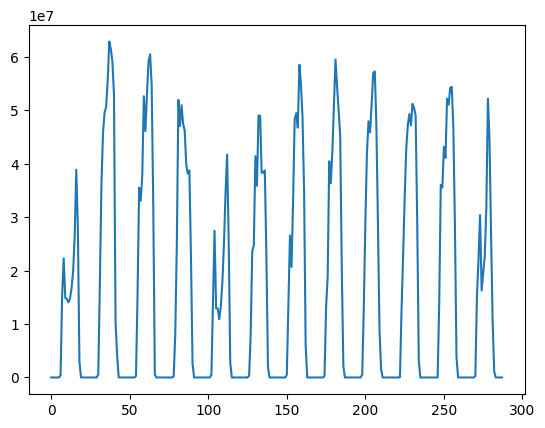

In [15]:
plt.plot(solar_mean_profile_aggregated)

In [16]:
try:
   #  print(f"\n--- Processando dados de Geração Eólica Reais (Média Agregada) do arquivo '{nome_do_arquivo_eolica}' ---")
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, N_intervals=N, unit_conversion_factor=1e6, sheet_name=0
    )
   #  print(f"Perfil Eólico de Média Agregada: {len(wind_mean_profile_aggregated)} pontos.")
   #  print("Primeiros 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[:10])
   #  print("Últimos 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[-10:])
   #  print("Valor máximo no perfil eólico agregado (Watts):", max(wind_mean_profile_aggregated))
   #  print("Valor mínimo no perfil eólico agregado (Watts):", min(wind_mean_profile_aggregated))
except (FileNotFoundError, ValueError) as e:
   #  print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO EÓLICO: {e} ***")
   #  print("A execução foi interrompida. Verifique o arquivo e o caminho.")
    exit()

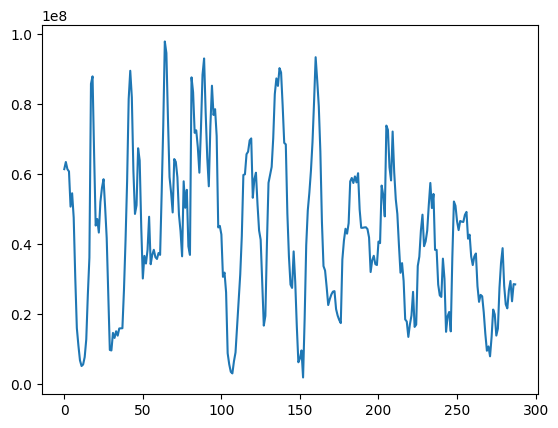

In [17]:
plt.plot(wind_mean_profile_aggregated)

In [18]:
h2_price_to_test = 10.00
ammonia_prices_to_test = [0.05, 1.50]

ammonia_price = ammonia_prices_to_test[0]


# A célula que carregava 'wind_mean_profile_aggregated' não é mais necessária

all_scenario_profiles = load_and_process_scenario_data(
         N=N,
         INTERVALO_HORAS=INTERVALO_HORAS,
         LOAD_MAX_W=LOAD_MAX_W,
         GEN_MAX_W=GEN_MAX_W,
         pld_data=pld_data_for_scenarios,
         solar_data=solar_data_for_scenarios,
         wind_data=wind_data_for_scenarios, 
         fixed_h2_price=h2_price_to_test,
         fixed_ammonia_price=ammonia_price
     )

print("\n✓ Perfis de cenário completos (PLD, Solar e Eólico estocásticos) foram gerados!")

"""
# Passamos os perfis de média agregada para solar e eólica para a função
all_scenario_profiles = load_and_process_scenario_data(
    N,
    INTERVALO_HORAS,
    LOAD_MAX_W,               # Carga máxima
    GEN_MAX_W,               # Geração Solar/Eólica máxima
    pld_data=pld_data_for_scenarios,
    solar_mean_profile=solar_mean_profile_aggregated,
    wind_mean_profile=wind_mean_profile_aggregated,
    fixed_h2_price=h2_price_to_test,
    fixed_ammonia_price=ammonia_price
)
"""

#   print("\nIniciando a resolução do Modelo Estocástico...")
all_scenario_names = ["optimal", "good", "bad"]
options = {"solver": "cplex"}

creator_with_data = lambda scenario_name, **kwargs: scenario_creator(
    scenario_name, all_profiles=all_scenario_profiles, **kwargs
)


✓ Perfis de cenário completos (PLD, Solar e Eólico estocásticos) foram gerados!


In [19]:
all_scenario_names

['optimal', 'good', 'bad']

In [20]:
all_scenario_profiles.keys()

dict_keys(['optimal', 'good', 'bad'])

In [21]:
all_scenario_profiles['optimal'].keys()

dict_keys(['spot_prices_mwh', 'solar_gen_w', 'wind_gen_w', 'load_w', 'h2_price_venda', 'ammonia_price_venda'])

In [26]:
creator_with_data('optimal')

In [27]:
options

{'solver': 'cplex'}

In [28]:
ef_builder = ExtensiveForm(options, all_scenario_names, creator_with_data)
solver = pyo.SolverFactory(options["solver"])
results = solver.solve(ef_builder.ef, tee=True)

if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
 #    print(f"\n--- Resultados da Otimização ---")
    ef_model = ef_builder.ef
    
    expected_profit = pyo.value(ef_model.EF_Obj)
    print(f"Valor Objetivo Ótimo (Lucro Esperado Total): R$ {expected_profit:,.2f}")
    
    first_block = getattr(ef_model, all_scenario_names[0])
    initial_socs = {
        'elec': pyo.value(first_block.X['ELEC_INITIAL_SOC']),
        'h2': pyo.value(first_block.X['H2_INITIAL_SOC']),
        'ammonia': pyo.value(first_block.X['AMMONIA_INITIAL_SOC'])
    }
  #   print("\nDecisões do Primeiro Estágio (aqui e agora):")
  #   print(f"  SOC Inicial Ótimo da BESS: {initial_socs['elec'] / 1e6:.2f} MWh")
  #   print(f"  SOC Inicial Ótimo do Tanque de H2: {initial_socs['h2']:.2f} kg")
   #  print(f"  SOC Inicial Ótimo do Tanque de Amônia: {initial_socs['ammonia']:.2f} kg")
    
   #  print("\nParâmetros Econômicos e de Conversão da Simulação:")
   #  print("-" * 50)
   #  print(f"  - Preço de Venda do H₂:       R$ {h2_price_to_test:.2f}/kg")
   #  print(f"  - Preço de Venda da Amônia:   R$ {ammonia_price:.2f}/kg")
    rendimento_h2_nh3 = 1 / TX_H2_TO_AMMONIA_KG_PER_KG
   #  print(f"  - Fator Haber-Bosch (Inverso): {rendimento_h2_nh3:.2f} kg de NH₃ gerados por kg de H₂")
   #  print("-" * 50)



[ 1804.02] Initializing SPBase

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.2.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2024.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmpksz3lfir.cplex.log' open.
CPLEX> Problem '/tmp/tmpmxce29gr.pyomo.lp' read.
Read time = 0.13 sec. (9.54 ticks)
CPLEX> Problem name         : /tmp/tmpmxce29gr.pyomo.lp
Objective sense      : Maximize
Variables            :   19881  [Nneg: 6048,  Box: 8649,  Binary: 5184]
Objective nonzeros   :    3456
Linear constraints   :   87405  [Less: 79623,  Equal: 7782]
  Nonzeros           :  192942
  RHS nonzeros       :   75294

Variables            : Min LB: 0.000000         Max UB: 2.000000e+08   
Objective nonzeros   : Min   : 4.741054e-06     Max   : 349771.7 

In [29]:
ef_model

In [30]:
getattr(ef_model, 'bad')

In [31]:
getattr(ef_model, 'good')

In [32]:
getattr(ef_model, 'optimal')

In [33]:
optimal_model = getattr(ef_model, 'optimal')

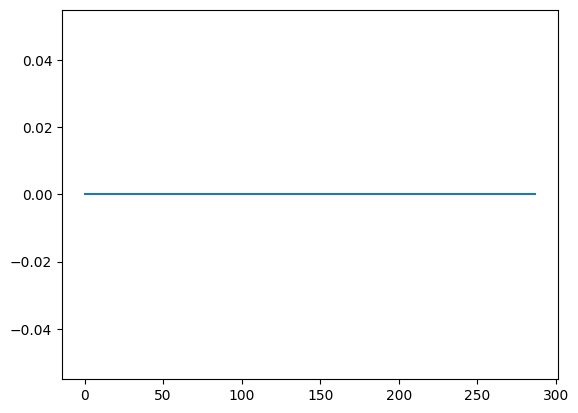

In [34]:
plt.plot(np.array([i.value for i in optimal_model.GRID_BUY_POWER.values()]))

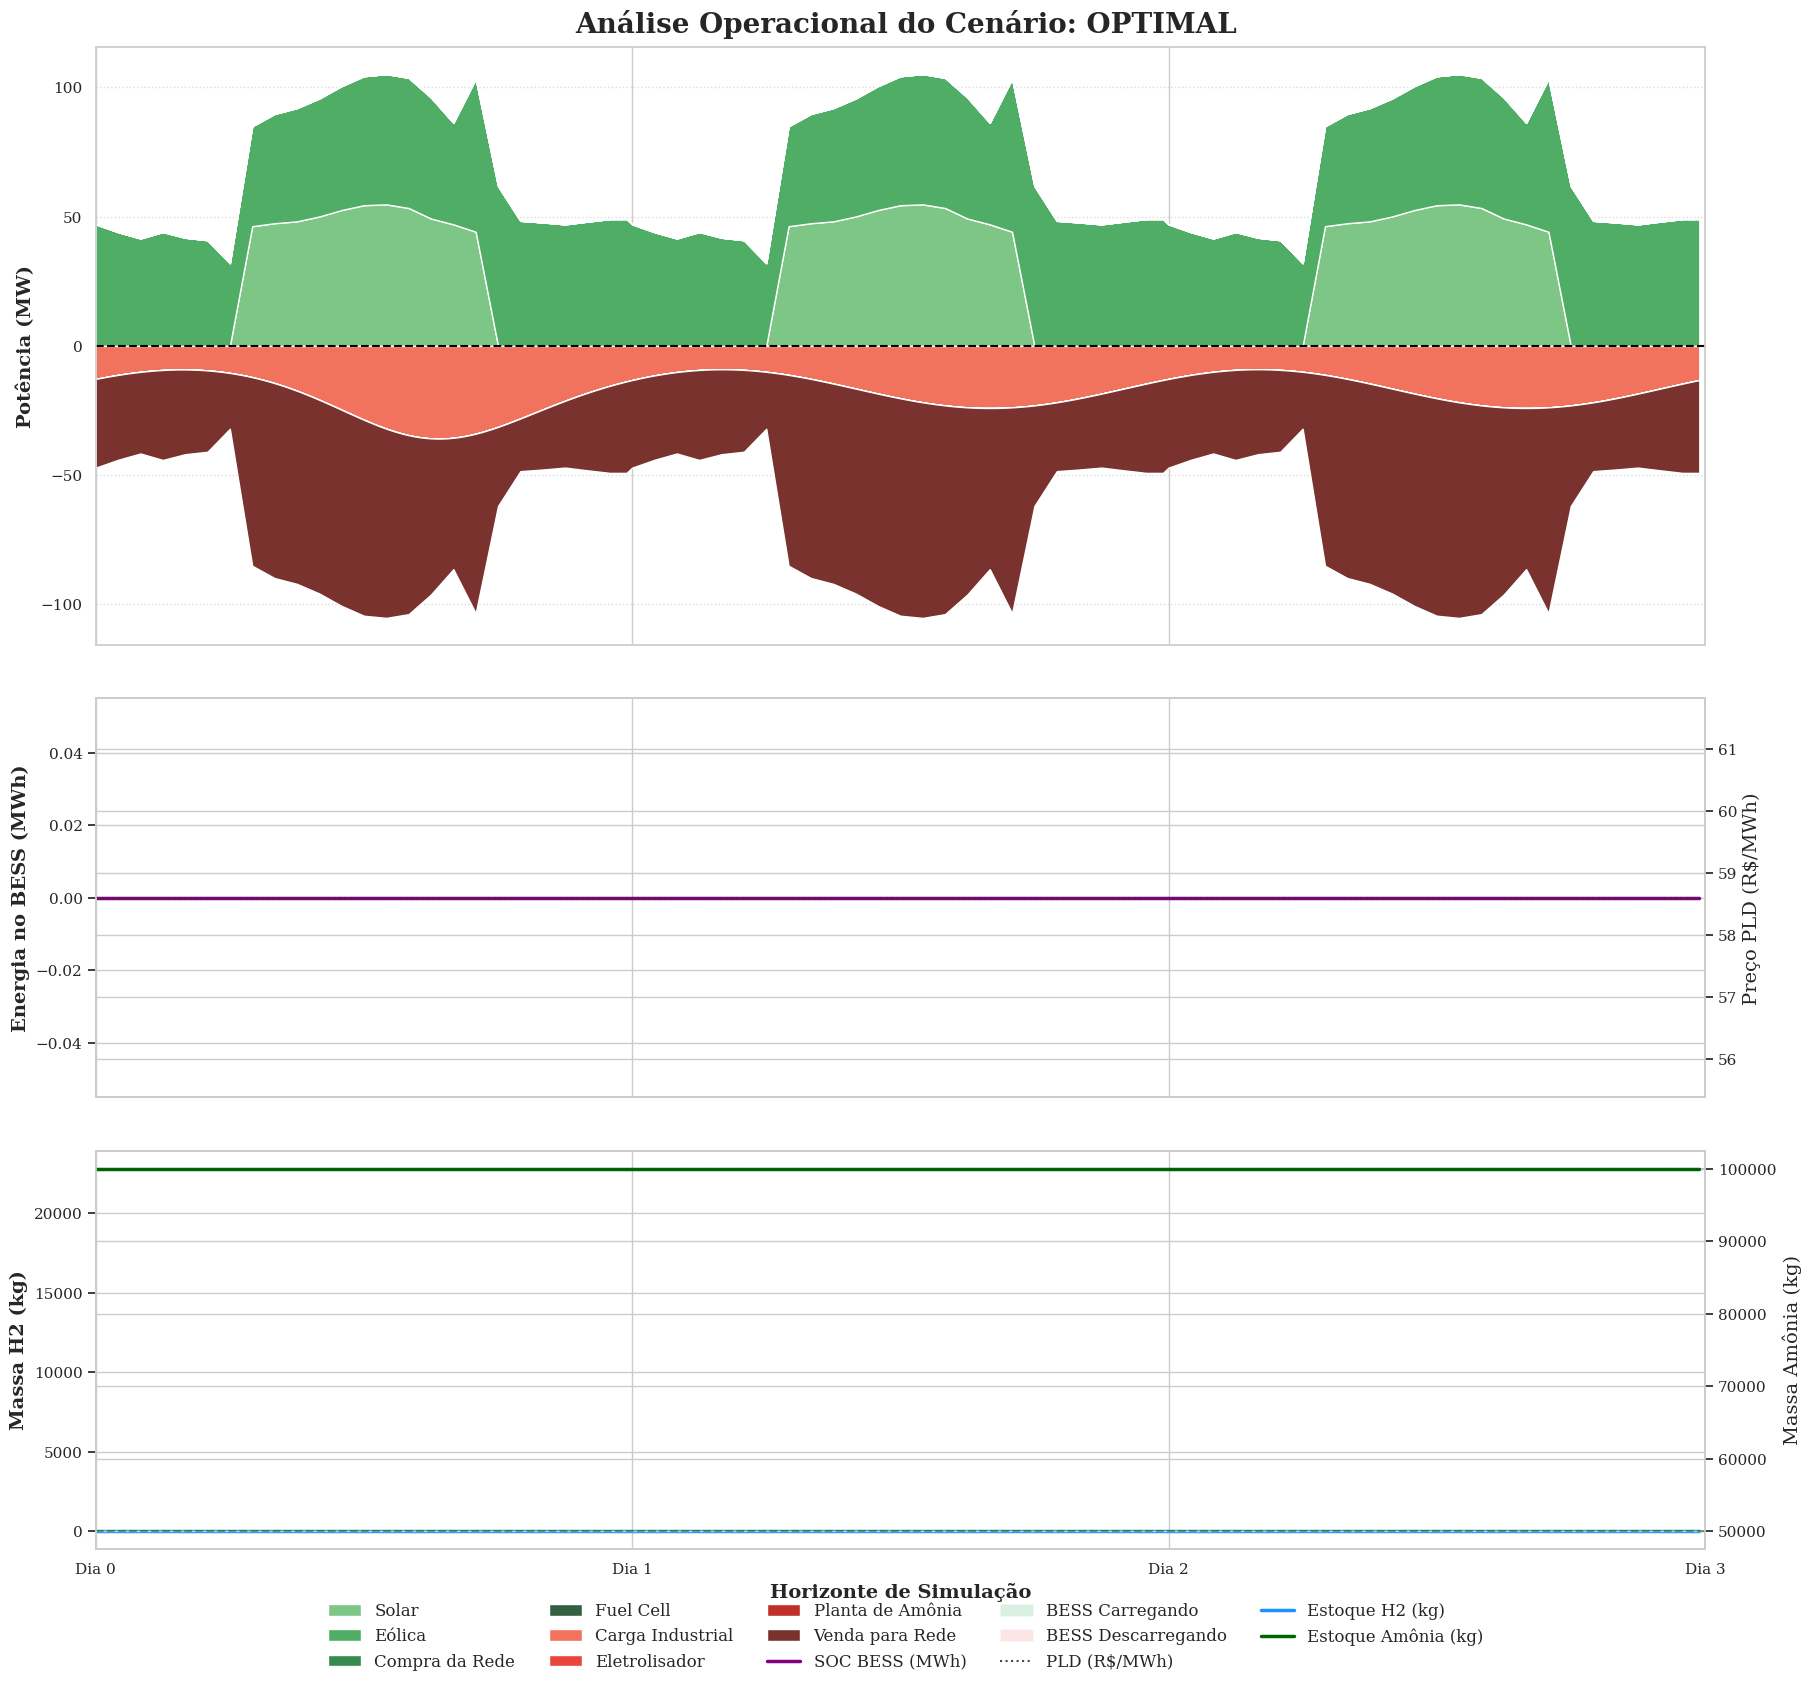

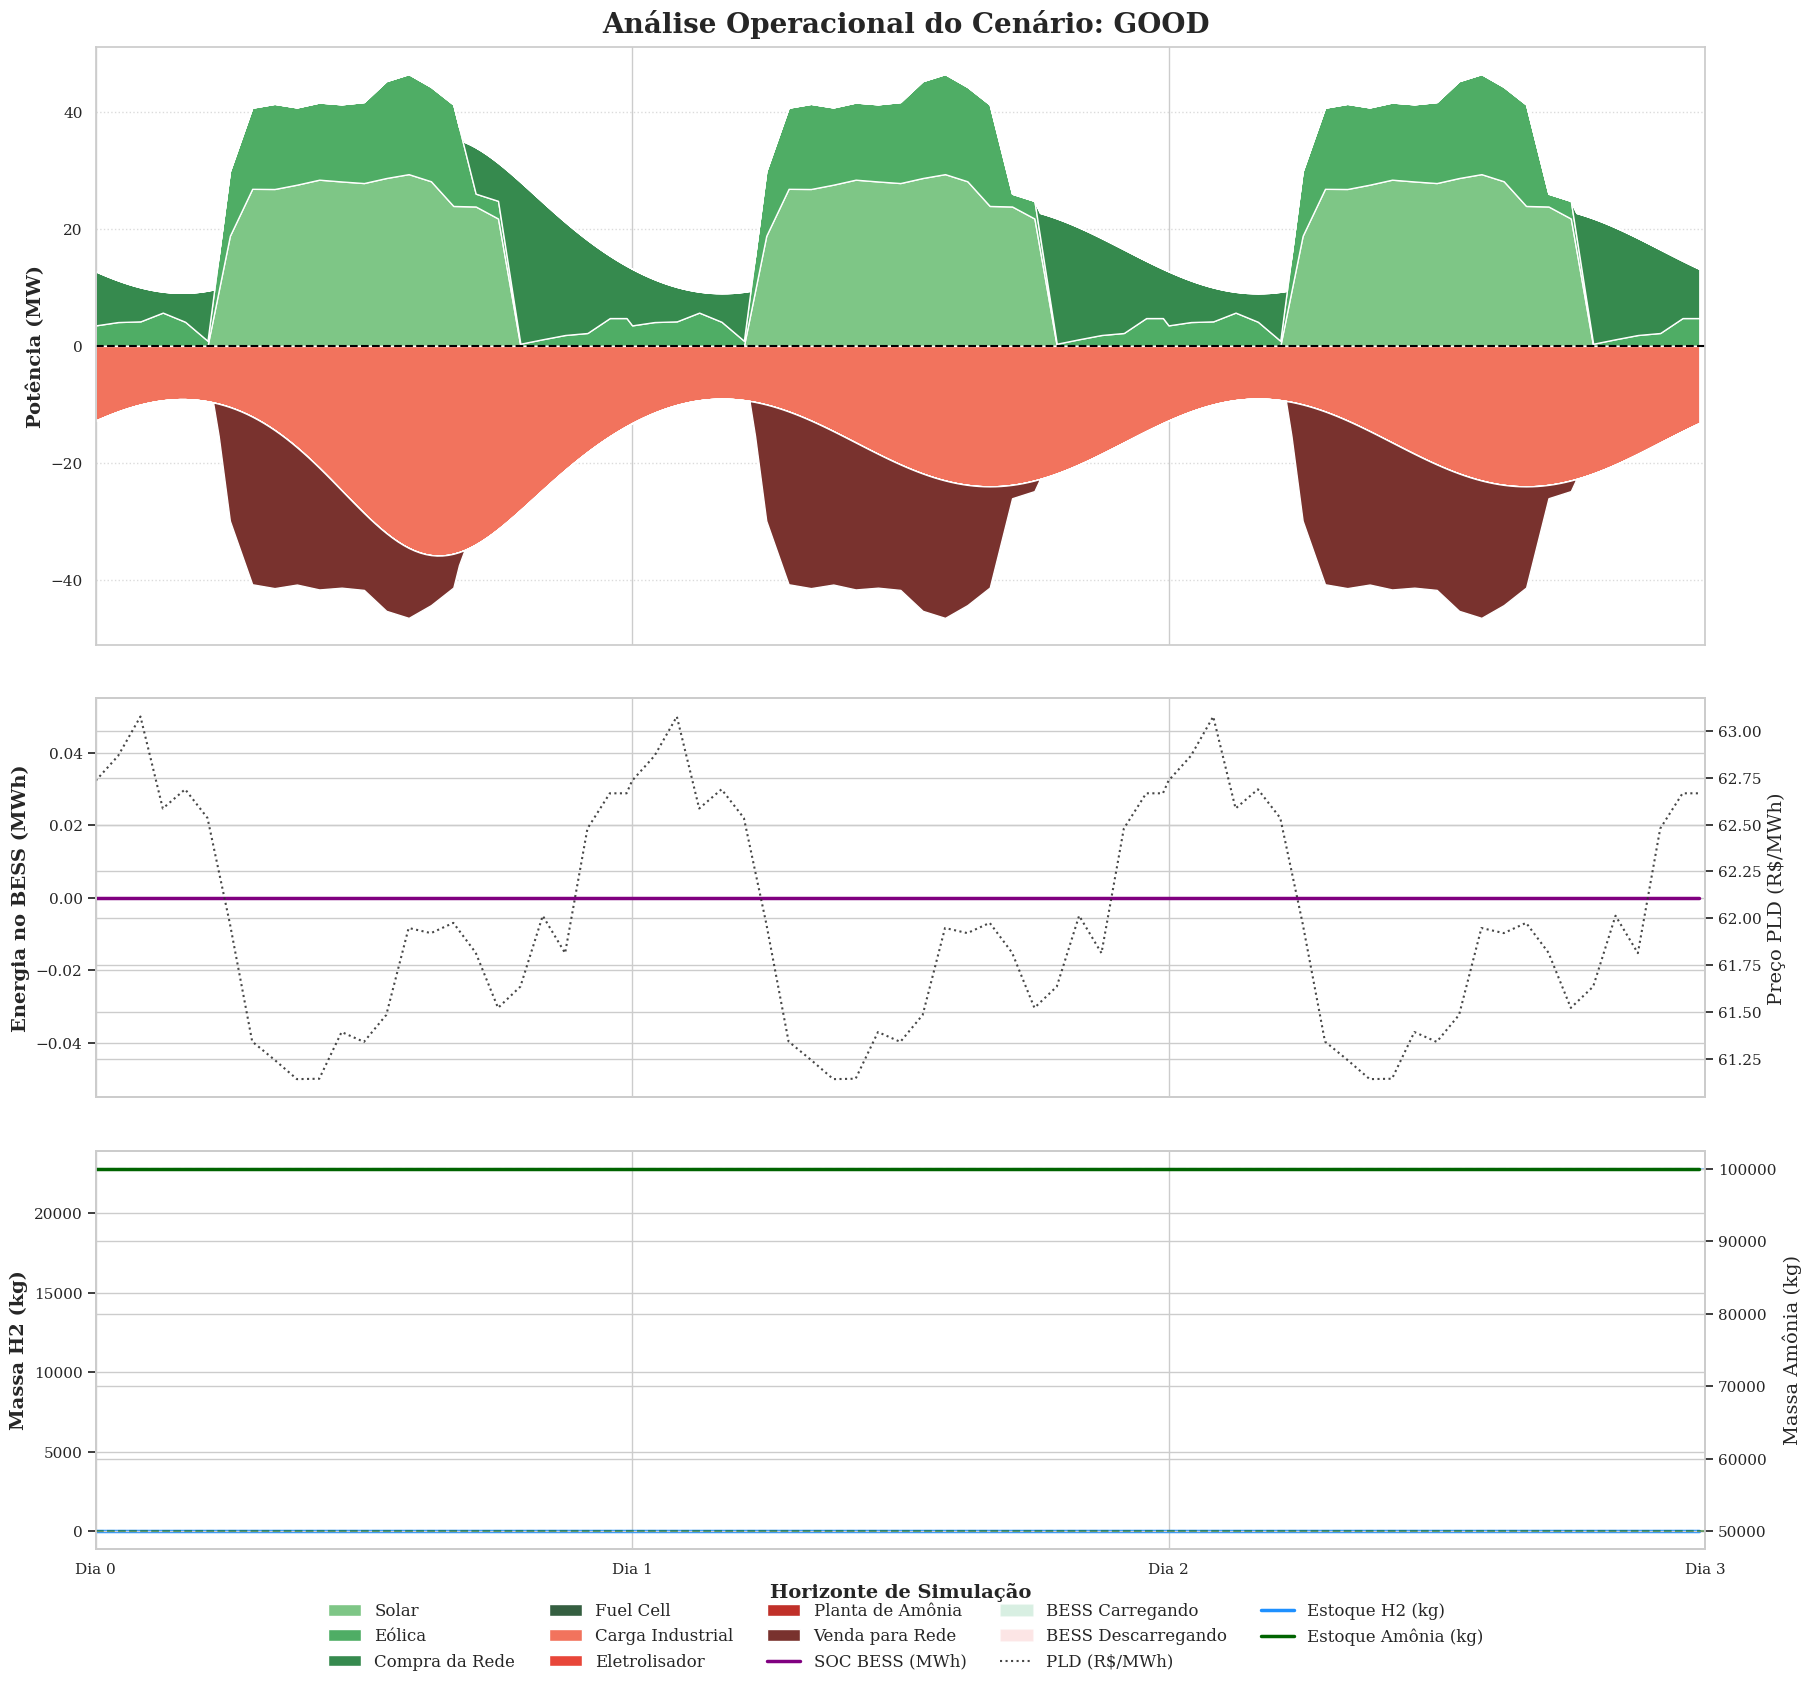

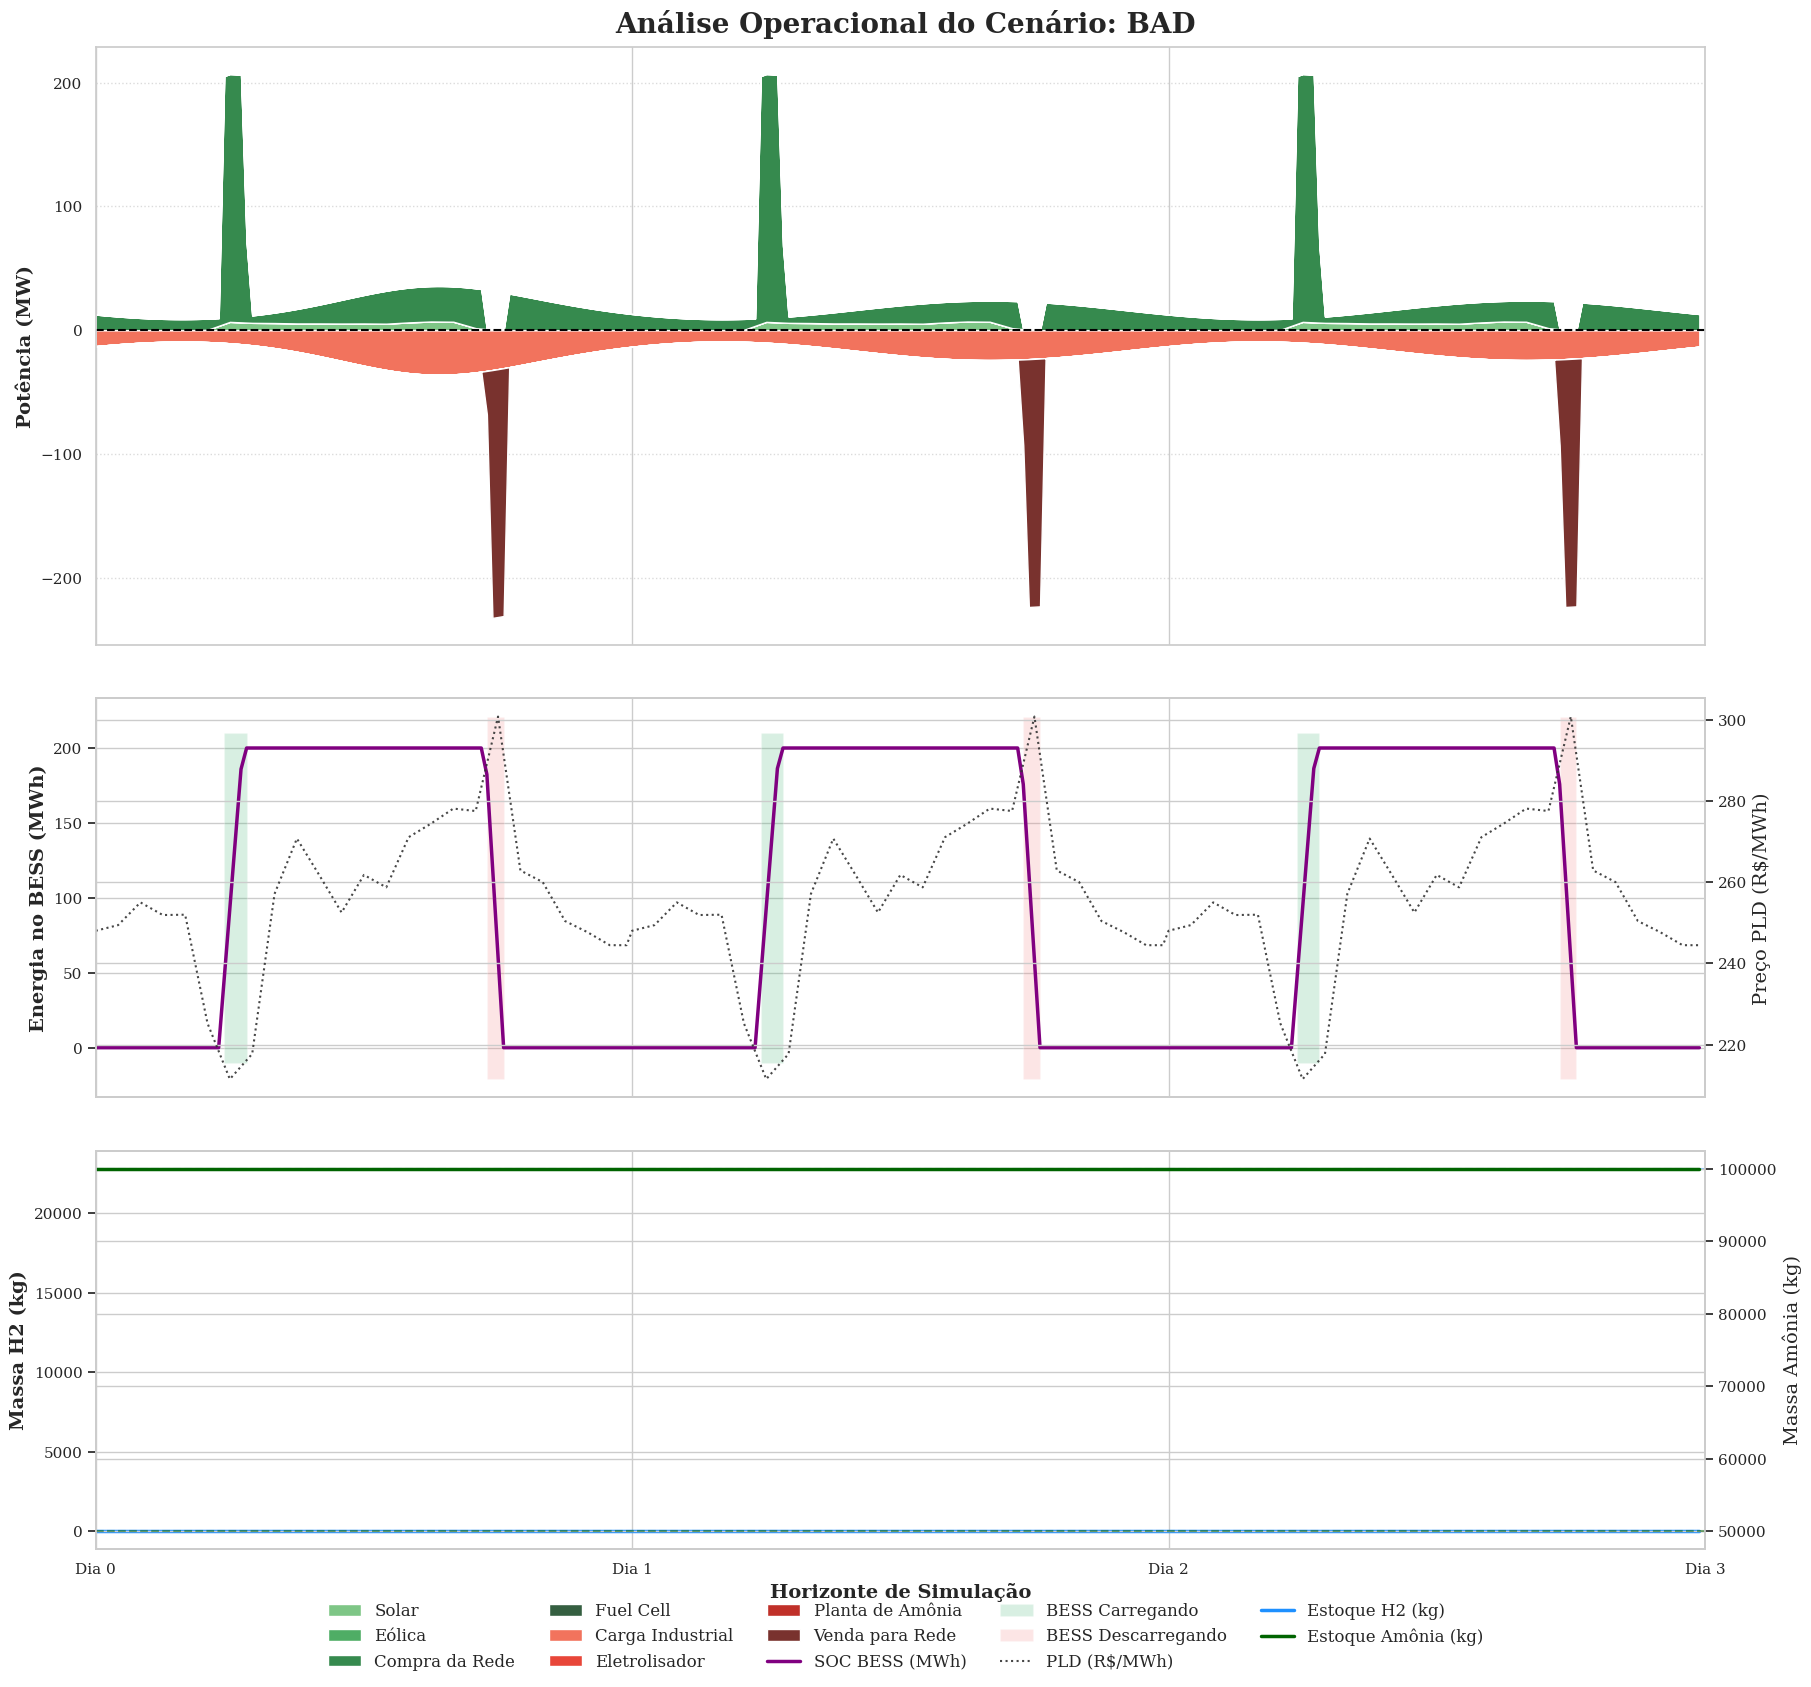

In [35]:
# --- Geração de Gráficos por Cenário ---
if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
    ef_model = ef_builder.ef
    
    # O TIME_HORIZON agora é um array de 1440 pontos
    for s_name in all_scenario_names:
        s_block = getattr(ef_model, s_name)
        
        plot_scenario_results(
            TIME_HORIZON,
            s_block, 
            s_name, 
            initial_socs, 
            fixed_h2_price=h2_price_to_test,
            fixed_ammonia_price=ammonia_price,
            AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG=AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG,
            INTERVALO_HORAS=INTERVALO_HORAS,
            N=N,
            h2_max_soc_kg=h2_max_soc_kg,
            h2_min_soc_kg=h2_min_soc_kg,
            ammonia_max_soc_kg=ammonia_max_soc_kg,
            ammonia_min_soc_kg=ammonia_min_soc_kg,
            TX_H2_TO_AMMONIA_KG_PER_KG=TX_H2_TO_AMMONIA_KG_PER_KG
        )
else:
    print(f"\nO solver não encontrou uma solução ótima. Condição: {results.solver.termination_condition}")

In [32]:
import pandas as pd
import pyomo.environ as pyo

# Garante que o modelo foi resolvido com sucesso antes de tentar analisar os resultados
if 'ef_model' in locals() and results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
    
    h2_allocation_data = []

    # Itera sobre cada um dos seus cenários ('bad', 'good', 'optimal')
    for s_name in all_scenario_names:
        s_block = getattr(ef_model, s_name)
        
        # Soma os valores das variáveis de interesse ao longo de todo o período de simulação
        total_h2_produced = sum(pyo.value(s_block.H2_PRODUCED[t]) for t in s_block.time)
        total_h2_to_ammonia = sum(pyo.value(s_block.H2_TO_AMMONIA_PLANT_MASS[t]) for t in s_block.time)
        total_h2_to_fuel_cell = sum(pyo.value(s_block.H2_TO_FUEL_CELL_MASS[t]) for t in s_block.time)
        
        # Calcula a variação líquida no estoque de H2 (o que foi armazenado)
        initial_h2_soc = pyo.value(s_block.X['H2_INITIAL_SOC'])
        final_h2_soc = pyo.value(s_block.H2_STORAGE_SOC[s_block.time.last()])
        net_h2_stored = final_h2_soc - initial_h2_soc
        
        h2_allocation_data.append({
            'Cenário': s_name.capitalize(),
            'H2 Total Produzido (kg)': total_h2_produced,
            'H2 para Amônia (kg)': total_h2_to_ammonia,
            'H2 para Fuel Cell (kg)': total_h2_to_fuel_cell,
            'H2 para Venda Direta (kg)': 0,  # Fixo em 0, pois o modelo não permite
            'Líquido Armazenado (kg)': net_h2_stored
        })

    # Cria um DataFrame do pandas para uma apresentação clara e profissional
    df_h2_allocation = pd.DataFrame(h2_allocation_data).set_index('Cenário')
    
    print("--- Análise de Alocação do Hidrogênio (H2) por Cenário ---")
    
    # Exibe a tabela formatada
    display(df_h2_allocation.style.format({
        'H2 Total Produzido (kg)': '{:,.2f}',
        'H2 para Amônia (kg)': '{:,.2f}',
        'H2 para Fuel Cell (kg)': '{:,.2f}',
        'H2 para Venda Direta (kg)': '{:,.2f}',
        'Líquido Armazenado (kg)': '{:,.2f}'
    }).background_gradient(cmap='viridis', subset=['H2 para Amônia (kg)', 'H2 para Fuel Cell (kg)']))

else:
    print("O modelo ainda não foi resolvido com sucesso. Por favor, execute a célula de otimização primeiro.")

--- Análise de Alocação do Hidrogênio (H2) por Cenário ---


,H2 Total Produzido (kg),H2 para Amônia (kg),H2 para Fuel Cell (kg),H2 para Venda Direta (kg),Líquido Armazenado (kg)
Cenário,,,,,
Optimal,"13,690.02","1,450.02","12,240.00",0.00,0.00
Good,0.00,0.00,0.00,0.00,0.00
Bad,0.00,0.00,0.00,0.00,0.00
